# Analysis

## Part 1. The whole dataset

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import math
import matplotlib as mpl

DATA_PATH = Path("data/vk_photos_perm_enriched.full.csv")
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows from {DATA_PATH}, columns: {', '.join(df.columns)}")
df.head(3)


Loaded 6,731 rows from data/vk_photos_perm_enriched.full.csv, columns: photo_id, owner_id, album_id, post_id, post_url, image_url, related_photo_urls, hashtags, date_human, lat, long, poi_lat, poi_lon, distance_meters, poi_name, user_id, user_gender, user_age, user_city, user_city_id, user_kind, post_text, inside_poi_area, inside_poi_building, annotation_text_description, annotation_location_type, annotation_photo_type, annotation_is_advertisement, annotation_city_objects, annotation_city_activities, annotation_user_intent, annotation_has_building, annotation_has_synagogue, annotation_has_feor, annotation_has_other_building, annotation_confidence, model_version, model_timestamp


True

In [318]:
selected_categories = pd.read_csv("data/фото феор синагога - Sheet1.csv")
selected_categories = selected_categories[~selected_categories["уровень восприятия"].isna()]
selected_categories.set_index("image_url", inplace=True)

selected = pd.merge(selected_categories, df, on="image_url", how="left")

In [319]:
selected

,image_url,уровень восприятия,объект,категория,image,annotation_text_description_x,annotation_user_intent_x,annotation_has_feor_x,первичный сюжет,Unnamed: 9,...,annotation_city_objects,annotation_city_activities,annotation_user_intent_y,annotation_has_building,annotation_has_synagogue,annotation_has_feor_y,annotation_has_other_building,annotation_confidence,model_version,model_timestamp
0,https://sun9-33.userapi.com/s/v1/if2/rnhSJ1xng...,уровень 0. урбанистический фон,ФЕОР снаружи,Урбанистический фон,NaN,Ночная городская улица: приближающийся автомоб...,задокументировать городскую сцену,yes,фон городской жизни,NaN,...,"дорога, автомобиль, фары, снег, бордюры, здани...",движение автомобиля,задокументировать городскую сцену,True,False,False,False,0.62,gpt-5-nano,2025-11-23T20:21:50.780931+00:00
1,https://sun9-56.userapi.com/s/v1/if2/h9LBHKJ_W...,уровень 0. урбанистический фон,ФЕОР снаружи,Урбанистический фон,NaN,Грузовик-крано-установка на городской улице; с...,показать строительную технику,yes,фон городской жизни,NaN,...,"тротуар, дорога, фасад здания, кран-автомобиль...",человек рядом с краном,показать строительную технику,True,False,False,False,0.79,gpt-5-nano,2025-11-23T20:21:50.795025+00:00
2,https://sun9-84.userapi.com/s/v1/ig2/t0btzbtYS...,уровень 0. урбанистический фон,ФЕОР снаружи,Урбанистический фон,NaN,Белый микроавтобус на тротуаре возле городског...,показать городской транспорт на улице,yes,фон городской жизни,NaN,...,"тротуар, дорога, автомобиль, здания, деревья",движение транспорта,показать городской транспорт на улице,True,False,False,False,0.74,gpt-5-nano,2025-11-23T20:21:50.844134+00:00
3,https://sun9-15.userapi.com/s/v1/if2/hFDo42nxw...,уровень 0. урбанистический фон,синагога снаружи,Урбанистический фон,NaN,"Автобус на снеговой улице, вокруг собираются л...",показать автобус на городской улице,yes,фон городской жизни,NaN,...,"автобус, люди, снег, тротуар, дорога, здания",посадка пассажиров,показать автобус на городской улице,True,False,False,True,0.79,gpt-5-nano,2025-11-23T20:21:50.792094+00:00
4,https://sun9-56.userapi.com/s/v1/ig2/CQZp15wpL...,уровень 0. урбанистический фон,синагога снаружи,Урбанистический фон,NaN,Жёлтый кабриолет на городской улице; впереди т...,показать автомобиль на городской улице,yes,NaN,NaN,...,"тротуар, дорога, фасады зданий, вывески, кабри...",проезд по улице,показать автомобиль на городской улице,True,False,False,True,0.79,gpt-5-nano,2025-11-23T20:21:50.817764+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,https://sun9-87.userapi.com/s/v1/ig2/hHbOMr5bk...,уровень 4*. жизнь общины,феор внутри,Деятельность школы / Контент общины,NaN,"Группа людей держит плакаты на улице, позируют...",задокументировать городскую scenу,NaN,NaN,NaN,...,"плакаты, люди, тротуар, плитка, здания, деревья","демонстрация, ходьба, держат плакаты",задокументировать городскую scenу,True,False,False,False,0.84,gpt-5-nano,2025-11-23T20:21:50.883748+00:00
175,https://sun9-75.userapi.com/s/v1/ig1/EpliTMB3V...,уровень 4*. жизнь общины,феор внутри,Деятельность школы / Контент общины,NaN,Девочка держит на тарелке круглую выпечку внут...,сделать портрет,NaN,NaN,NaN,...,NaN,NaN,сделать портрет,False,False,False,False,0.72,gpt-5-nano,2025-11-23T20:21:50.885261+00:00
176,https://sun9-19.userapi.com/s/v1/if1/e3dGRO-dK...,уровень 4*. жизнь общины,феор внутри,Деятельность школы / Контент общины,NaN,детская игровая площадка на улице с ярко окраш...,показать детскую игровую площадку,NaN,NaN,NaN,...,"детская площадка, воздушные шары, кирпичная ст...",игры на детской площадке,показать детскую игровую площадку,True,False,False,False,0.79,gpt-5-nano,2025-11-23T20:21:50.885283+00:00
177,https://sun9-60.userapi.com/s/v1/ig2/Wf5TLvZpX...,уровень 4*. жизнь общины,феор внутри,Деятельность школы / Контент общины,NaN,Молодой мужчина в синем свитере стоит на желто...,портрет человека в помещении,NaN,NaN,NaN,...,"человек, стена, чашка, палочки с фруктами",NaN,портрет человека в помещении,Fal

In [327]:
selected_with_context = pd.read_csv("data/selected_with_context.csv")
selected = pd.merge(selected, selected_with_context[["image_url", "context"]], on="image_url", how="outer")


In [328]:

selected['wall_url'] = selected.user_id.map(lambda user_id: f'https://vk.com/wall{int(user_id)}')
selected['user_type'] = selected.user_id.map(lambda user_id: 'group' if user_id < 0 else 'user')
selected['level'] = selected['уровень восприятия']
selected['year'] = selected['date_human'].astype(str).str[:4]
selected['poi_name_ru'] = selected['poi_name'].apply(lambda x: "Синагога" if x == "synagogue" else "ФЕОР")

selected


,image_url,уровень восприятия,объект,категория,image,annotation_text_description_x,annotation_user_intent_x,annotation_has_feor_x,первичный сюжет,Unnamed: 9,...,model_version,model_timestamp,context_x,wall_url,user_type,level,year,poi_name_ru,context_y,context
0,https://sun9-1.userapi.com/s/v1/ig1/_19WV_Ge_o...,уровень 2. утилитарность,синагога внутри,Коммерческая экосистема,NaN,Крупный план руки с маникюром: ногти тёпло-роз...,показать маникюр как услугу,NaN,NaN,NaN,...,gpt-5-nano,2025-11-23T20:21:50.771061+00:00,Лучшие друзья девушек - это💎💎💎\n\n ♥️Новый ман...,https://vk.com/wall-124299091,group,уровень 2. утилитарность,2019,Синагога,Лучшие друзья девушек - это💎💎💎\n\n ♥️Новый ман...,Лучшие друзья девушек - это💎💎💎\n\n ♥️Новый ман...
1,https://sun9-10.userapi.com/s/v1/ig1/emPjVWX3Q...,уровень 3. музей,синагога снаружи,Архитектурная доминанта / Наследие,NaN,Городской пейзаж вдоль улицы: передний план — ...,задокументировать городской пейзаж,yes,часть городского пейзажа / фасад,NaN,...,gpt-5-nano,2025-11-23T20:21:50.869781+00:00,NaN,https://vk.com/wall537376289,user,уровень 3. музей,2019,Синагога,NaN,NaN
2,https://sun9-11.userapi.com/s/v1/if2/vVj5obVFo...,уровень 3. музей,синагога снаружи,Архитектурная доминанта / Наследие,NaN,"Жёлтое деревянное здание на улице в снегу, пер...",показать фасад здания,yes,фасад,NaN,...,gpt-5-nano,2025-11-23T20:21:50.786202+00:00,"Екатерининская ул., 116 (58.008119, 56.234707)...",https://vk.com/wall-216919326,group,уровень 3. музей,2022,Синагога,"Екатерининская ул., 116 (58.008119, 56.234707)...","Екатерининская ул., 116 (58.008119, 56.234707)..."
3,https://sun9-11.userapi.com/s/v1/ig1/OqD8DZTLL...,уровень 4*. жизнь общины,синагога внутри,Сакральное ядро / Контент общины,NaN,На длинных столах в помещении расставлены голу...,показать мусор и упаковку на столах внутри пом...,NaN,NaN,NaN,...,gpt-5-nano,2025-11-23T20:21:50.877518+00:00,NaN,https://vk.com/wall-46008634,group,уровень 4*. жизнь общины,2017,Синагога,NaN,NaN
4,https://sun9-11.userapi.com/s/v1/ig1/yG7m7b_Nm...,уровень 4*. жизнь общины,феор внутри,Деятельность школы / Контент общины,NaN,Группа из трёх школьниц стоит перед чёрной дос...,показать школьное выступление перед классом,NaN,NaN,NaN,...,gpt-5-nano,2025-11-23T20:21:50.839530+00:00,NaN,https://vk.com/wall-67125411,group,уровень 4*. жизнь общины,2017,ФЕОР,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,https://sun9-88.userapi.com/s/v1/ig2/JSc36_KxJ...,уровень 4*. жизнь общины,феор внутри,Деятельность школы / Контент общины,NaN,"Три женщины стоят на улице, позируют перед кам...",позирование группы на улице,NaN,NaN,NaN,...,gpt-5-nano,2025-11-23T20:21:50.772002+00:00,NaN,https://vk.com/wall-76634753,group,уровень 4*. жизнь общины,2022,ФЕОР,NaN,NaN
175,https://sun9-88.userapi.com/s/v1/ig2/Kgr8dGk3e...,уровень 1. маскировка,синагога снаружи,Сцена для самопрезентации,NaN,Человек в чёрном длинном пуховике с капюшоном ...,показать человека в зимнем пальто на улице,yes,дворик / портрет,NaN,...,gpt-5-nano,2025-11-23T20:21:50.810443+00:00,Ежедневно ждем вас в KOLIBRI ❤️\n\n Приглашаем...,https://vk.com/wall-194619161,group,уровень 1. маскировка,2024,Синагога,Ежедневно ждем вас в KOLIBRI ❤️\n\n Приглашаем...,Ежедневно ждем вас в KOLIBRI ❤️\n\n Приглашаем...
176,https://sun9-88.userapi.com/s/v1/ig2/V7NNmtrve...,уровень 4*. жизнь общины,феор внутри,Деятельность школы / Контент общины,NaN,Группа людей сидит за длинным столом в светлой...,показать группу людей за столом во время трапезы,NaN,NaN,NaN,...,gpt-5-nano,2025-11-23T20:21:50.814118+00:00,NaN,https://vk.com/wall-76634753,group,уровень 4*. жизнь общины,2022,ФЕОР,NaN,NaN
177,https://sun9-88.userapi.com/s/v1/ig2/iR1Vv9KZQ...,уровень 4*. жизнь общины,феор внутри,Деятельность школы / Контент общины,NaN,Две девушки сидят за столом в помещении. На ст...,показать дружескую встречу за столом с едой,NaN,NaN,NaN,...,gpt-5-nano,2025-11-23T20:21:50.833194+00:00,NaN,https://vk.com/wall-76634753,group,уровен

In [329]:
len(selected['wall_url'].unique())


70

In [338]:
selected[["user_type", "wall_url", "date_human", "post_text", "level", "context"]]
selected[["post_text", "context", "level", "poi_name_ru"]].to_csv("data/selected_with_context_and_level.csv", index=False)

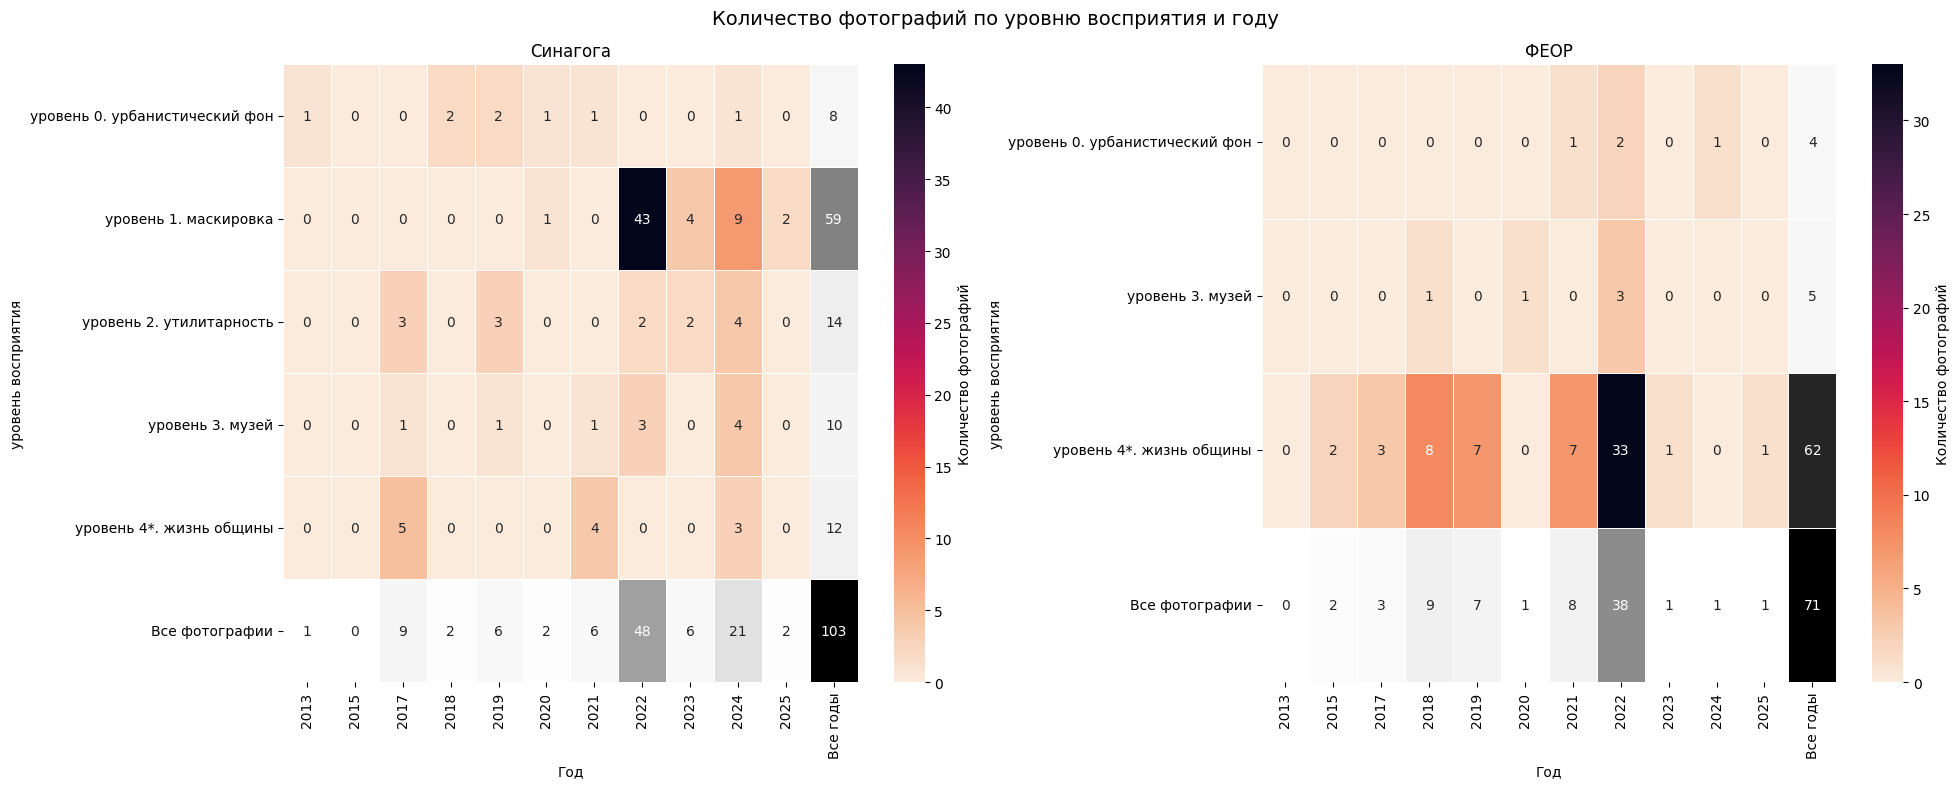

In [275]:
import matplotlib.pyplot as plt
import seaborn as sns



def plot_photo_type_heatmaps_by_poi(df: pd.DataFrame) -> None:
    """Draw one heatmap per POI showing how photo types change over time."""
    data = df.copy()

    if "year" not in data.columns:
        data["date"] = pd.to_datetime(data["date_human"])
        data["year"] = data["date"].dt.year

    data["poi_name"] = data["poi_name_ru"].fillna("unknown")
    data["annotation_photo_type"] = data["annotation_photo_type"].fillna("other")
    data = data[data["annotation_photo_type"] != "other"]

    years = sorted(y for y in data["year"].dropna().unique())
    if not years:
        print("No year information available for plotting")
        return

    pois = sorted(data["poi_name"].unique())
    cols = 2  # tweak to taste
    rows = math.ceil(len(pois) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 10, rows * 8), squeeze=False)
    for ax, poi in zip(axes.flat, pois):
        poi_data = data[data["poi_name"] == poi]

        if poi_data.empty:
            continue
        # unique by user_id 
        pivot = (
            poi_data.pivot_table(
                index="level",
                columns="year",
                values="photo_id",
                aggfunc="nunique",
                fill_value=0,
            ).reindex(columns=years, fill_value=0)
        )

        if pivot.empty:
            continue


        all_years_text = "Все годы"
        all_photos_text = "Все фотографии"
        pivot[all_years_text] = pivot.sum(axis=1)

        totals_row = pivot.sum(axis=0).to_frame().T
        totals_row.index = [all_photos_text]
        pivot = pd.concat([pivot, totals_row])
        pivot = pivot[[*years, all_years_text]]

        totals_row = pivot.index == all_photos_text
        totals_col = pivot.columns == all_years_text
        totals_mask = np.logical_or.outer(totals_row, totals_col)

        sns.heatmap(
            pivot,
            mask=totals_mask,
            cmap="rocket_r",
            linewidths=0.4,
            linecolor="white",
            annot=True,
            fmt="g",
            cbar_kws={"label": "Количество фотографий"},
            ax=ax,
        )
        sns.heatmap(
            pivot,
            mask=~totals_mask,
            cmap="Greys",
            linewidths=0.4,
            linecolor="white",
            annot=True,
            fmt="g",
            cbar=False,
            ax=ax,
        )
        ax.set_title(poi)
        ax.set_xlabel("Год")
        ax.set_ylabel("уровень восприятия")

    for ax in axes.flat[len(pois):]:
        ax.axis("off")
    
    fig.suptitle("Количество фотографий по уровню восприятия и году", fontsize=14, y=0.98)
    fig.tight_layout()


plot_photo_type_heatmaps_by_poi(selected)


In [263]:
selected.to_csv("data/vk_photos_perm_selected.csv")

In [283]:
print('\n'.join(list(selected.columns)))


image_url
уровень восприятия_x
объект_x
категория_x
image_x
annotation_text_description_x_x
annotation_user_intent_x_x
annotation_has_feor_x_x
первичный сюжет_x
Unnamed: 9_x
Unnamed: 10_x
photo_id_x
owner_id_x
album_id_x
post_id_x
post_url_x
related_photo_urls_x
hashtags_x
date_human_x
lat_x
long_x
poi_lat_x
poi_lon_x
distance_meters_x
poi_name_x
user_id_x
user_gender_x
user_age_x
user_city_x
user_city_id_x
user_kind_x
post_text_x
inside_poi_area_x
inside_poi_building_x
annotation_text_description_y_x
annotation_location_type_x
annotation_photo_type_x
annotation_is_advertisement_x
annotation_city_objects_x
annotation_city_activities_x
annotation_user_intent_y_x
annotation_has_building_x
annotation_has_synagogue_x
annotation_has_feor_y_x
annotation_has_other_building_x
annotation_confidence_x
model_version_x
model_timestamp_x
wall_url_x
user_type_x
level_x
year_x
poi_name_ru_x
Unnamed: 1_x
date_human_y
wall_url_y
context_x
user_type_y
post_id_y
post_url_y
уровень восприятия_y
объект_y
к

In [282]:
years = sorted(y for y in selected["year"].dropna().unique())

selected[selected.poi_name == "synagogue"].pivot_table(
                index="level",
                columns="year",
                values="photo_id",
                aggfunc="nunique",
                fill_value=0,
            ).reindex(columns=years, fill_value=0)

year,2013,2014,2015,2017,2018,2019,2020,2021,2022,2023,2024,2025
level,,,,,,,,,,,,
уровень 0. урбанистический фон,1,1,0,0,2,2,1,1,0,0,1,0
уровень 1. маскировка,0,0,0,0,0,0,1,0,43,4,9,2
уровень 2. утилитарность,0,0,0,3,0,3,0,0,2,2,4,0
уровень 3. музей,0,0,0,1,0,1,0,1,3,0,4,0
уровень 4*. жизнь общины,0,0,0,5,0,0,0,4,0,0,4,0


In [ ]:
years = sorted(y for y in selected["year"].dropna().unique())

selected[selected.poi_name != "synagogue"].pivot_table(
                index="level",
                columns="year",
                values="photo_id",
                aggfunc="nunique",
                fill_value=0,
            ).reindex(columns=years, fill_value=0)

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
level,,,,,,,,,,,,,
уровень 0. урбанистический фон,0,0,0,0,0,0,0,0,1,2,0,1,0
уровень 3. музей,0,0,0,0,0,1,0,1,0,1,0,0,0
уровень 4*. жизнь общины,0,0,1,0,2,2,2,0,1,2,1,0,1


# Архив

In [229]:
total = len(df)
print(f"Total rows: {total}")

# Photos by POI name and year
df["date"] = pd.to_datetime(df["date_human"])
df["year"] = df["date"].dt.year
df["poi_name"] = df["poi_name"].fillna("unknown")

Total rows: 6731


In [154]:
total_df = pd.read_csv("data/vk_photos_perm_historical_with_polygons_new.csv")
total_synagogue = len(total_df[total_df.poi_name == "synagogue"])
total_feor = len(total_df) - total_synagogue

synagogue_territory = len(total_df[(total_df.poi_name == "synagogue") & total_df.inside_poi_building])
synagogue_visibility = len(total_df[(total_df.poi_name == "synagogue") & total_df.inside_poi_area & ~total_df.inside_poi_building])

feor_territory = len(total_df[(total_df.poi_name != "synagogue") & total_df.inside_poi_building])
feor_visibility = len(total_df[(total_df.poi_name != "synagogue") & total_df.inside_poi_area  & ~total_df.inside_poi_building])

total_synagogue - (synagogue_visibility + synagogue_territory)

final_dataset_size = 179

In [54]:
visibility_with_buildings = df[df.annotation_has_building & (df.annotation_location_type != "indoor")]
synagogue_visibility_with_buildings = len(visibility_with_buildings[visibility_with_buildings.poi_name == "synagogue"])
feor_visibility_with_buildings = len(visibility_with_buildings[visibility_with_buildings.poi_name != "synagogue"])
synagogue_visibility_with_buildings_non_indoor = None

In [123]:
! pip install kaleido


[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [157]:
final_dataset_size

179

In [187]:
import plotly.graph_objects as go

# -------------------
# Theme colors (links + nodes)
# -------------------
COLOR_SYNAGOGUE_LINK = "rgba(64,55,205,0.85)"
COLOR_FEOR_LINK = "rgba(240,138,28,0.85)"
# COLOR_SELECTED_LINK = "rgba(0,146,92,0.8)"
COLOR_FILTERED_LINK = "rgba(140,140,140,0.35)"
COLOR_SELECTED_LINK = "rgba(84, 173, 139, 0.85)"
COLOR_DEFAULT_LINK = "rgba(120,120,120,0.35)"
COLOR_FINAL_LINK = "rgba(0,146,92,0.8)"

COLOR_SYNAGOGUE_NODE = "rgba(64,55,205,0.95)"
COLOR_FEOR_NODE = "rgba(240,138,28,0.95)"
# COLOR_SELECTED_NODE = "rgba(0,146,92,0.9)"
COLOR_FILTERED_NODE = "rgba(90,90,90,0.85)"
COLOR_SELECTED_NODE = "rgba(84, 173, 139, 0.85)"
COLOR_DEFAULT_NODE = "rgba(110,110,110,0.85)"
COLOR_FINAL_NODE = "green"

# -------------------
# 1. Data
# -------------------
data = [
    ("Фото в радиусе 100 метров от синагоги", "Синагога в зоне видимости", synagogue_visibility),
    ("Фото в радиусе 100 метров от синагоги", "Внутри здания синагоги", synagogue_territory),
    ("Фото в радиусе 100 метров от синагоги", "Отфильтровано", total_synagogue - (synagogue_visibility + synagogue_territory)),

    ("Фото в радиусе 100 метров от ФЕОРа", "ФЕОР в зоне видимости", feor_visibility),
    ("Фото в радиусе 100 метров от ФЕОРа", "Внутри здания и внутреннего двора ФЕОРа", feor_territory),
    ("Фото в радиусе 100 метров от ФЕОРа", "Отфильтровано", total_feor - (feor_territory + feor_visibility)),

    ("ФЕОР в зоне видимости", "ФЕОР в зоне видимости и на фотографии есть здание", feor_visibility_with_buildings),
    ("ФЕОР в зоне видимости", "Отфильтровано", feor_visibility - feor_visibility_with_buildings),
    
    ("Синагога в зоне видимости", "Синагога в зоне видимости и на фотографии есть здание", synagogue_visibility_with_buildings),
    ("Синагога в зоне видимости", "Отфильтровано", synagogue_visibility - synagogue_visibility_with_buildings),

    ("Синагога в зоне видимости и на фотографии есть здание", "Всего отобрано для анализа", synagogue_visibility_with_buildings),
    ("ФЕОР в зоне видимости и на фотографии есть здание", "Всего отобрано для анализа", feor_visibility_with_buildings),
    ("Внутри здания синагоги", "Всего отобрано для анализа", synagogue_territory),
    ("Внутри здания и внутреннего двора ФЕОРа", "Всего отобрано для анализа", feor_territory),

    ("Всего отобрано для анализа", "Финальный датасет", final_dataset_size),
    ("Всего отобрано для анализа", "Отфильтровано", synagogue_visibility_with_buildings + feor_visibility_with_buildings + synagogue_territory + feor_territory - final_dataset_size)
]

# -------------------
# 2. Nodes & ordering
# -------------------
labels = []
for s, t, _ in data:
    if s not in labels:
        labels.append(s)
    if t not in labels:
        labels.append(t)

preferred_order = [
    "Фото в радиусе 100 метров от синагоги",
    "Синагога в зоне видимости",
    "Синагога в зоне видимости и на фотографии есть здание",
    "Внутри здания синагоги",
    "Фото в радиусе 100 метров от ФЕОРа",
    "ФЕОР в зоне видимости",
    "ФЕОР в зоне видимости и на фотографии есть здание",
    "Внутри здания и внутреннего двора ФЕОРа",
    "Всего отобрано для анализа",
    "Отфильтровано",
    "Финальный датасет",
]
original_order = {label: idx for idx, label in enumerate(labels)}
labels = sorted(
    labels,
    key=lambda label: (
        preferred_order.index(label) if label in preferred_order else len(preferred_order) + original_order[label]
    ),
)

label_index = {label: i for i, label in enumerate(labels)}

sources = [label_index[s] for s, t, v in data]
targets = [label_index[t] for s, t, v in data]
values = [v for s, t, v in data]

# -------------------
# 3. Coloring helpers
# -------------------
def pick_link_color(source: str, target: str) -> str:
    target_l = target.lower()
    source_l = source.lower()
    if "отфильтровано" in target_l:
        return COLOR_FILTERED_LINK
    if "отобрано" in target_l:
        return COLOR_SELECTED_LINK
    if "синагог" in source_l:
        return COLOR_SYNAGOGUE_LINK
    if "феор" in source_l:
        return COLOR_FEOR_LINK
    if "финальный датасет" in target_l:
        return COLOR_FINAL_LINK
    return COLOR_DEFAULT_LINK


def pick_node_color(label: str) -> str:
    label_l = label.lower()
    if "отфильтровано" in label_l:
        return COLOR_FILTERED_NODE
    if "отобрано" in label_l:
        return COLOR_SELECTED_NODE
    if "синагог" in label_l:
        return COLOR_SYNAGOGUE_NODE
    if "феор" in label_l:
        return COLOR_FEOR_NODE
    if "финальный датасет" in label_l:
        return COLOR_FINAL_NODE
    return COLOR_DEFAULT_NODE


link_colors = [pick_link_color(s, t) for (s, t, _) in data]
node_colors = [pick_node_color(label) for label in labels]

# -------------------
# 4. Totals in node labels
# -------------------
totals = {label: 0 for label in labels}
for (s, t, v) in data:
    totals[s] += v
for (s, t, v) in data:
    if "Финальный датасет" in t or "Отфильтровано" in t:
        totals[t] += v

label_aliases = {
    "Фото в радиусе 100 метров от синагоги": "100 м от синагоги",
    "Фото в радиусе 100 метров от ФЕОРа": "100 м от ФЕОРа",
    "Синагога в зоне видимости": "Синагога в зоне\nвидимости",
    "ФЕОР в зоне видимости": "ФЕОР в зоне\nвидимости",
    "Синагога в зоне видимости и на фотографии есть здание": "На фото есть здание (у синагоги)",
    "ФЕОР в зоне видимости и на фотографии есть здание": "На фото есть здание (у ФЕОРА)",
    "Внутри здания синагоги": "Внутри\nсинагоги",
    "Внутри здания и внутреннего двора ФЕОРа": "Внутри пространства\nФЕОР",
    "Всего отобрано для анализа": "Ручной отбор",
    "Финальный датасет": "Отобрано",
}

def format_label(label: str) -> str:
    short = label_aliases.get(label, label)
    return short.replace("\n", "<br>") + f"<br><b>{totals[label]}</b>"

labels_with_totals = [format_label(label) for label in labels]

# -------------------
# 5. Node layout for readability
# -------------------
node_positions = {
    # Левая колонка (0)
    "Фото в радиусе 100 метров от синагоги": (0.02, 0.2),
    "Фото в радиусе 100 метров от ФЕОРа":     (0.02, 0.7),

    # Вторая колонка (1)
    "Синагога в зоне видимости":              (0.18, 0.5),
    "ФЕОР в зоне видимости":                  (0.18, 0.8),
    # Третья колонка (2)
    "Внутри здания синагоги":                 (0.18, 0.6),
    "Синагога в зоне видимости и на фотографии есть здание": (0.34, 0.75),

    "Внутри здания и внутреннего двора ФЕОРа": (0.18, 0.90),
    "ФЕОР в зоне видимости и на фотографии есть здание":      (0.34, 0.87),

    # Четвёртая колонка (3) — фильтрованные
    "Всего отобрано для анализа":             (0.54, 0.60),

    "Отфильтровано":                          (0.9, 0.2),

    # Пятая колонка (4)
    "Финальный датасет":                      (0.9, 0.9),
}

default_position = (0.9, 0.5)
node_coords = [node_positions.get(label, default_position) for label in labels]
node_x = [coord[0] for coord in node_coords]
node_y = [coord[1] for coord in node_coords]

# -------------------
# 6. Sankey figure (static friendly)
# -------------------
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="freeform",
            node=dict(
                label=labels_with_totals,
                pad=26,
                thickness=22,
                color=node_colors,
                line=dict(color="white", width=1),
                x=node_x,
                y=node_y,
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
                color=link_colors,
                line=dict(color="rgba(255,255,255,0.4)", width=0.5),
            ),
            domain=dict(x=[0.02, 0.98], y=[0.02, 0.8]),
        )
    ]
)

fig.update_traces(node=dict(hoverinfo="skip"), link=dict(hoverinfo="skip"))


fig.update_layout(
    title_text="Отбор фотографий: Синагога и ФЕОР",
    title_x=0.35,
    font=dict(size=13, family="PT Sans"),
    width=1150,
    height=650,
    margin=dict(l=20, r=260, t=80, b=20),
    paper_bgcolor="white",
    plot_bgcolor="white",
)

try:
    fig.write_image("newplot_.png", scale=2)
except ValueError:
    print("Установите 'pip install plotly[kaleido]' для экспорта PNG")

fig.show()


Установите 'pip install plotly[kaleido]' для экспорта PNG


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_poi_year_counts(df, name="Total photos"):
    poi_year_counts = df.groupby(["poi_name", "year"]).size().reset_index(name="count")
    plt.figure(figsize=(8, 4))
    sns.barplot(x="year", y="count", hue="poi_name", data=poi_year_counts)
    plt.title(f"{name} by POI name and year")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.legend(title="POI Name")

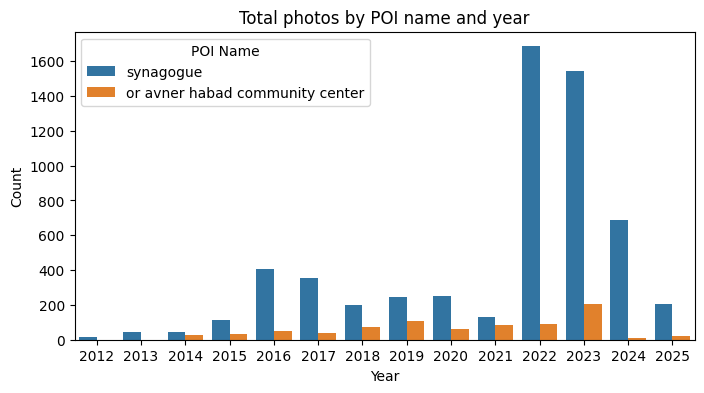

In [5]:
visualize_poi_year_counts(df)

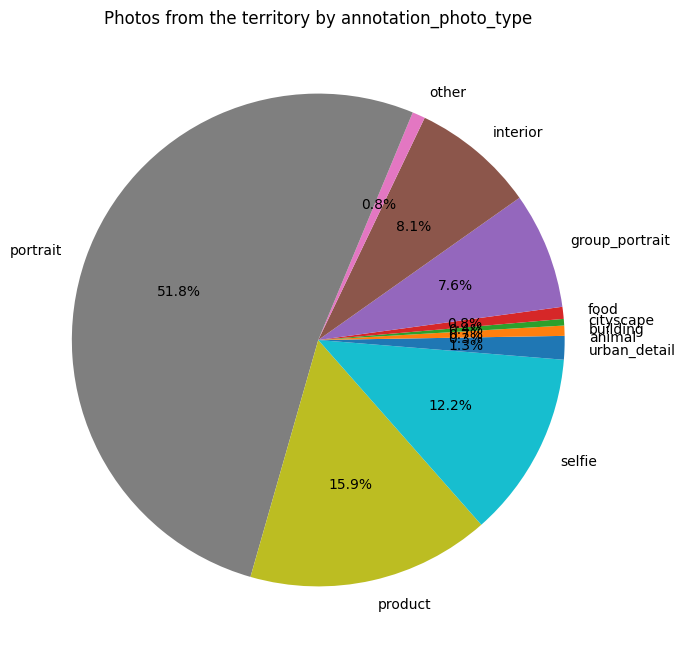

In [6]:
def visualize_photo_types(df, name="Photos from the territory"):
    grouped = df.groupby(["annotation_photo_type"]).size().reset_index(name="count")
    # a pie chart with annotation_photo_type count
    plt.figure(figsize=(8, 8))
    plt.pie(grouped["count"], labels=grouped["annotation_photo_type"], autopct="%1.1f%%")
    plt.title(f"{name} by annotation_photo_type")
    plt.show()

visualize_photo_types(df)


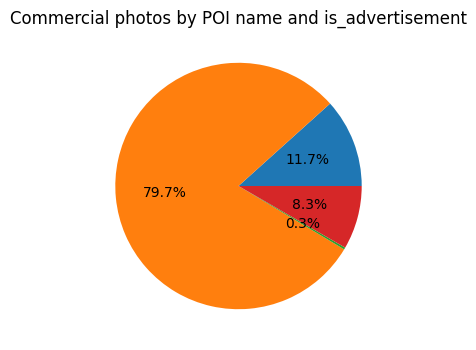

In [7]:
def visualize_commercial_photos_by_poi(df):
    grouped = df.groupby(["annotation_is_advertisement", "poi_name"]).size().reset_index(name="count")
    grouped["share"] = grouped["count"] / grouped.groupby("poi_name")["count"].transform("sum") * 100
    # a pie chart with share of the total by poi_name for each annotation_is_advertisement
    plt.figure(figsize=(8, 4))
    plt.pie(grouped["count"], autopct="%1.1f%%")
    plt.title(f"Commercial photos by POI name and is_advertisement")
    plt.show()

visualize_commercial_photos_by_poi(df)

### Part 1.1
Photos from the buildings territories. 

In [13]:
synagogue_polygon = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "coordinates": [
          [
            [
              56.23496489283937,
              58.00802808622268
            ],
            [
              56.23491384496796,
              58.00811952458747
            ],
            [
              56.23485064284006,
              58.008109221684606
            ],
            [
              56.23467805241583,
              58.008397701837936
            ],
            [
              56.2344349673113,
              58.00835391482161
            ],
            [
              56.23467075986346,
              58.007973995812335
            ],
            [
              56.23496489283937,
              58.00802808622268
            ]
          ]
        ],
        "type": "Polygon"
      }
    }
  ]
}


from shapely.geometry import shape, Point

synagogue_poly = shape(synagogue_polygon["features"][0]["geometry"])

syn_df = df[df["poi_name"].str.lower() == "synagogue"].copy()
syn_df = syn_df.dropna(subset=["lat", "long"])

syn_df["inside_custom_poly"] = syn_df.apply(
    lambda row: synagogue_poly.contains(Point(row["long"], row["lat"])),
    axis=1,
)

print(
    f"{syn_df['inside_custom_poly'].sum()} / {len(syn_df)} "
    "synagogue photos inside custom polygon"
)


syn_df[syn_df["inside_custom_poly"]][["image_url", "photo_id", "user_id", "date_human", "annotation_text_description", "annotation_user_intent", "annotation_has_building"]].to_csv("synagogue_inside_custom_poly.csv", index=False)


113 / 5928 synagogue photos inside custom polygon


In [ ]:
inside_building_mask = df["inside_poi_building"].fillna(False)
inside_df = df[inside_building_mask]
print(f"Photos from the buildings territories: {len(inside_df):,}")




Photos from the buildings territories: 377


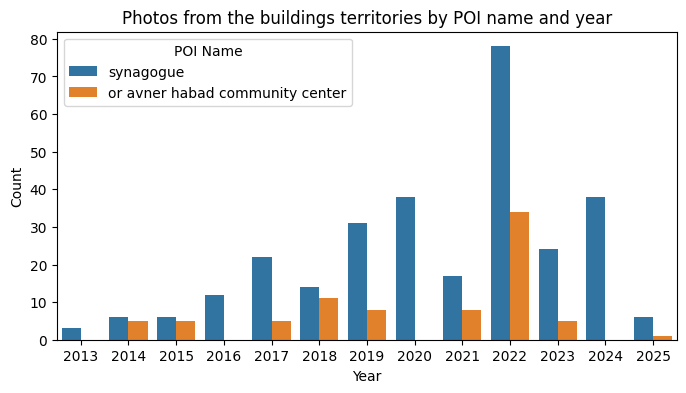

In [181]:
### Photos from the building 
visualize_poi_year_counts(inside_df, name="Photos from the buildings territories")

In [182]:
def visualize_poi_location_type(df, name="Photos from the territory"):
    grouped = df.groupby(["poi_name", "annotation_location_type"]).size().reset_index(name="count")
    grouped["share"] = grouped["count"] / grouped.groupby("poi_name")["count"].transform("sum") * 100
    # make two pie charts, one for each poi_name
    plt.figure(figsize=(8, 4))
    for i, poi_name in enumerate(grouped["poi_name"].unique()):
        poi_data = grouped[grouped["poi_name"] == poi_name]
        plt.subplot(1, 2, i + 1)
        plt.pie(poi_data["count"], labels=poi_data["annotation_location_type"], autopct="%1.1f%%")
        plt.title(f"{name} of {poi_name} by location type")
        plt.show()


/var/folders/yz/1n0b98zd7zqcxhyl8wl435h40000gn/T/ipykernel_78144/3962888877.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inside_df["annotation_location_type"] = inside_df["annotation_location_type"].fillna("unknown")


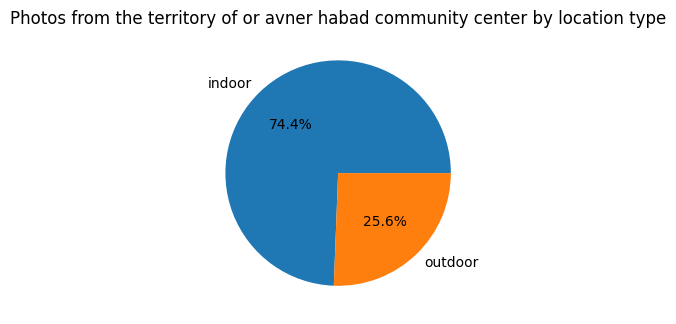

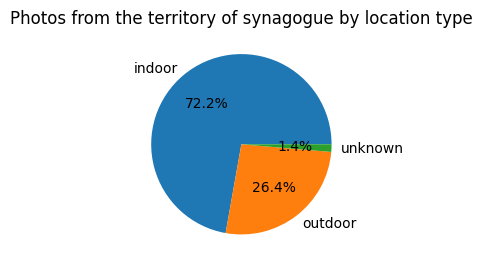

In [183]:
# Photos from the buildings territories by poi and annotation_location_type, share of the total by poi
inside_df["annotation_location_type"] = inside_df["annotation_location_type"].fillna("unknown") 
visualize_poi_location_type(inside_df)

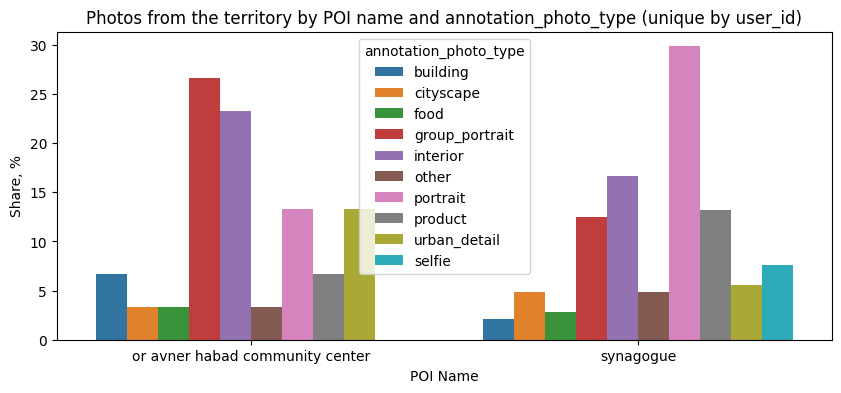

In [ ]:
def visualize_poi_photo_type(df, name="Photos from the territory"):
    # unique by user_id 
    # grouped = df.groupby(["poi_name", "annotation_photo_type"]).size().reset_index(name="count")
    grouped = df.groupby(["poi_name", "annotation_photo_type", "user_id"]).size().reset_index(name="user_count").groupby(["poi_name", "annotation_photo_type"]).size().reset_index(name="count")
    grouped["share"] = grouped["count"] / grouped.groupby("poi_name")["count"].transform("sum") * 100
    # a bar chart with share of the total by poi_name for each annotation_photo_type
    plt.figure(figsize=(10, 4))
    sns.barplot(x="poi_name", y="share", hue="annotation_photo_type", data=grouped)
    plt.title(f"{name} by POI name and annotation_photo_type (unique by user_id)")
    plt.xlabel("POI Name")
    plt.ylabel("Share, %")
    plt.show()

visualize_poi_photo_type(inside_df)

In [215]:
inside_df[inside_df.poi_name == "or avner habad community center"][["image_url", "annotation_text_description", "annotation_user_intent", "annotation_has_feor"]].to_csv("or_avner_habad_community_center_inside.csv", index=False)
inside_df[inside_df.poi_name == "synagogue"][["image_url", "annotation_text_description", "annotation_user_intent", "annotation_has_synagogue"]].to_csv("synagogue_inside.csv", index=False)

In [205]:
df.groupby(["poi_name", "annotation_photo_type", "user_id"]).size().reset_index(name="user_count").groupby(["poi_name", "annotation_photo_type"]).size().reset_index(name="count")

,poi_name,annotation_photo_type,count
0,or avner habad community center,animal,8
1,or avner habad community center,building,18
2,or avner habad community center,cityscape,6
3,or avner habad community center,food,10
4,or avner habad community center,group_portrait,45
5,or avner habad community center,interior,51
6,or avner habad community center,other,11
7,or avner habad community center,portrait,75
8,or avner habad community center,product,27
9,or avner habad community center,selfie,22


In [224]:
years = sorted(y for y in df["year"].dropna().unique())

df.pivot_table(
                index="annotation_photo_type",
                columns="year",
                values="user_id",
                aggfunc="nunique",
                fill_value=0,
            ).reindex(columns=years, fill_value=0)

year,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
annotation_photo_type,,,,,,,,,,,,,,
animal,1,0,0,0,0,6,0,4,2,0,2,0,0,0
building,0,2,1,1,2,3,4,4,2,3,5,1,4,2
cityscape,0,1,0,0,3,2,2,4,0,1,9,1,1,1
food,0,1,0,2,1,2,5,1,4,3,6,0,0,0
group_portrait,2,4,10,14,10,23,21,15,9,8,17,10,5,10
interior,0,5,8,12,14,15,26,22,15,9,23,9,15,6
other,1,1,3,4,12,5,2,6,3,1,2,3,1,0
portrait,1,6,17,26,30,41,37,31,26,20,34,19,24,9
product,2,4,4,7,17,16,12,22,20,10,18,7,10,3


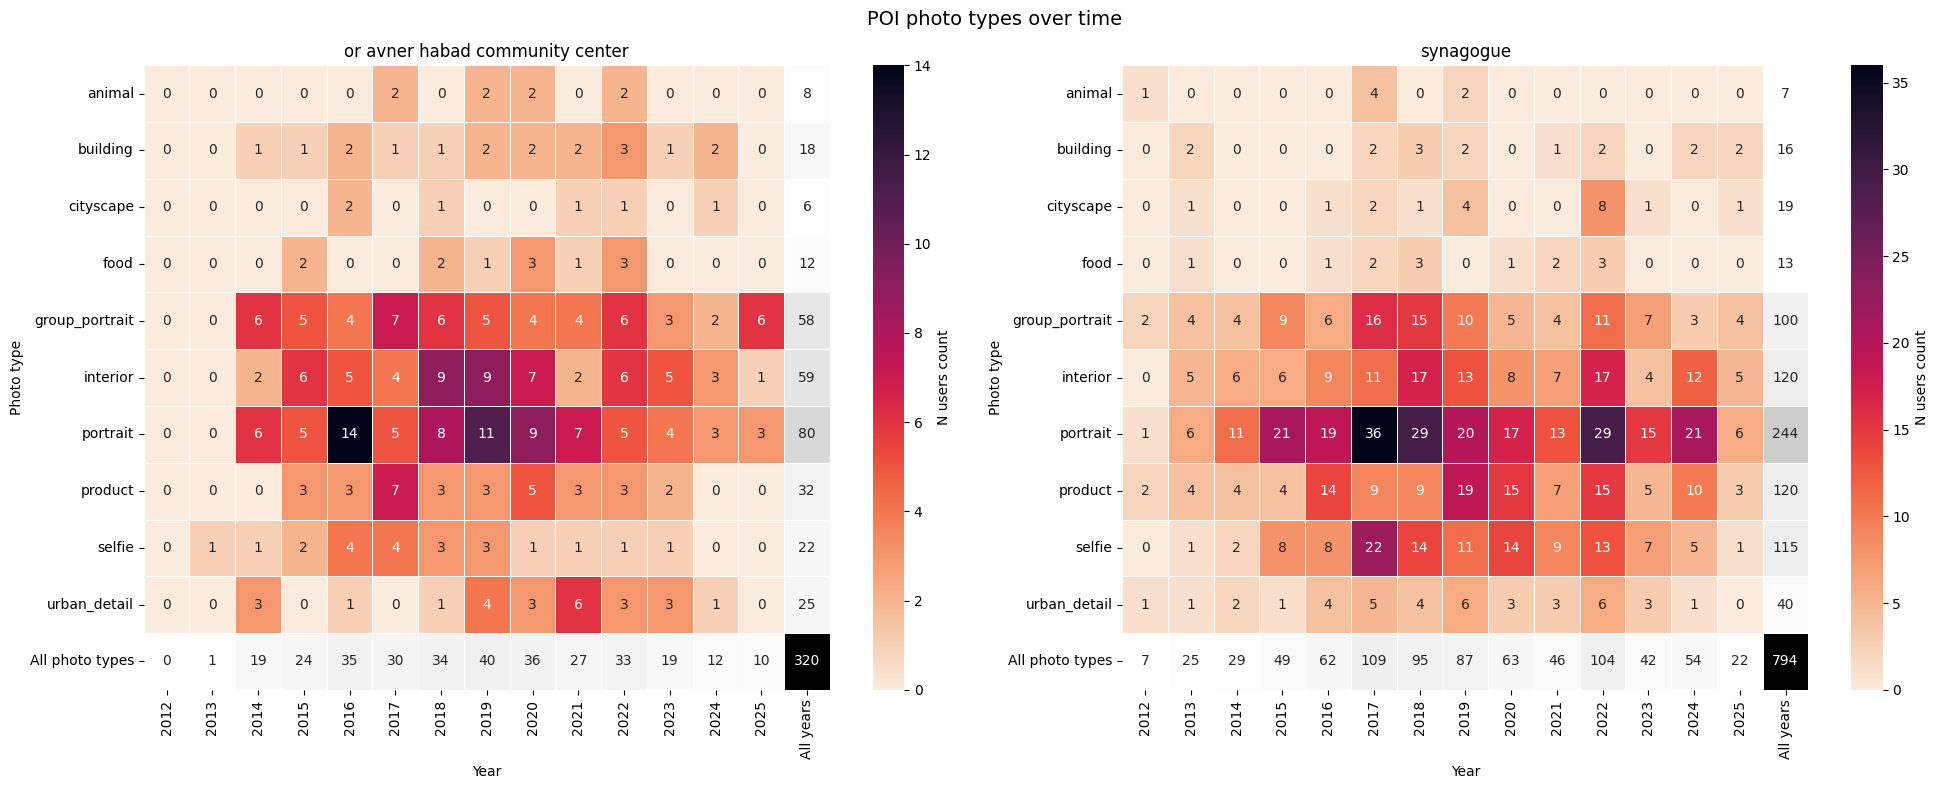

In [245]:
def plot_photo_type_heatmaps_by_poi(df: pd.DataFrame) -> None:
    """Draw one heatmap per POI showing how photo types change over time."""
    data = df.copy()

    if "year" not in data.columns:
        data["date"] = pd.to_datetime(data["date_human"])
        data["year"] = data["date"].dt.year

    data["poi_name"] = data["poi_name"].fillna("unknown")
    data["annotation_photo_type"] = data["annotation_photo_type"].fillna("other")
    data = data[data["annotation_photo_type"] != "other"]

    years = sorted(y for y in data["year"].dropna().unique())
    if not years:
        print("No year information available for plotting")
        return

    pois = sorted(data["poi_name"].unique())
    cols = 2  # tweak to taste
    rows = math.ceil(len(pois) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 10, rows * 8), squeeze=False)
    for ax, poi in zip(axes.flat, pois):
        poi_data = data[data["poi_name"] == poi]
        if poi_data.empty:
            continue
        # unique by user_id 
        pivot = (
            poi_data.pivot_table(
                index="annotation_photo_type",
                columns="year",
                values="user_id",
                aggfunc="nunique",
                fill_value=0,
            )
            .reindex(columns=years, fill_value=0)
        )

        if pivot.empty:
            continue

        # order = pivot.sum(axis=1).sort_values(ascending=False).index
        # pivot = pivot.reindex(order)

        # add totals for rows (all years) and columns (all photo types)
        pivot["All years"] = pivot.sum(axis=1)
        # order = (
        #     pivot.drop(index="All photo types", errors="ignore")
        #     .sort_values("All years", ascending=False)
        #     .index.tolist()
        # )
        # pivot = pivot.loc[order]

        totals_row = pivot.sum(axis=0).to_frame().T
        totals_row.index = ["All photo types"]
        pivot = pd.concat([pivot, totals_row])
        pivot = pivot[[*years, "All years"]]

        totals_row = pivot.index == "All photo types"
        totals_col = pivot.columns == "All years"
        totals_mask = np.logical_or.outer(totals_row, totals_col)

        sns.heatmap(
            pivot,
            mask=totals_mask,
            cmap="rocket_r",
            linewidths=0.4,
            linecolor="white",
            annot=True,
            fmt="g",
            cbar_kws={"label": "N users count"},
            ax=ax,
        )
        sns.heatmap(
            pivot,
            mask=~totals_mask,
            cmap="Greys",
            linewidths=0.4,
            linecolor="white",
            annot=True,
            fmt="g",
            cbar=False,
            ax=ax,
        )
        ax.set_title(poi)
        ax.set_xlabel("Year")
        ax.set_ylabel("Photo type")

    for ax in axes.flat[len(pois):]:
        ax.axis("off")
    # fig.colorbar(
    #     mpl.cm.ScalarMappable(cmap="rocket_r"),
    #     ax=axes,
    #     orientation="vertical",
    #     label="Photo count",
    #     fraction=0.02,
    #     pad=0.02,
    # )
    fig.suptitle("POI photo types over time", fontsize=14, y=0.98)
    fig.tight_layout()


plot_photo_type_heatmaps_by_poi(df)


### Part 1.2
Photos from areas of visibility with building in it

In [186]:
# DATA_BUILDING_PATH = Path("data/vk_photos_perm_enriched.building_flags_applied.csv")
# buildings_df = pd.read_csv(DATA_BUILDING_PATH)


In [190]:
building_mask = df["annotation_has_building"].fillna(False) & (df['annotation_location_type'] == "outdoor")
buildings_df = df[building_mask]

print(f"Photos from areas of visibility with building in them: {len(buildings_df):,}")

Photos from areas of visibility with building in them: 334


In [191]:
buildings_df.head(3)

,photo_id,owner_id,album_id,post_id,post_url,image_url,related_photo_urls,hashtags,date_human,lat,...,annotation_user_intent,annotation_has_building,annotation_has_synagogue,annotation_has_feor,annotation_has_other_building,annotation_confidence,model_version,model_timestamp,date,year
13,426439526,-58351133,235375970,NaN,NaN,"https://sun9-82.userapi.com/s/v1/ig1/EeOdHg7Z3Mns2qWiscfz4xzeKykALU5g4ob875hcPy9oIE-Od5Shp2mc6Ec_AwWvuqEVIxX_.jpg?quality=96&as=32x43,48x64,72x96,108x144,160x214,240x320,360x481,480x641,540x721,640x855,719x960&from=bu&cs=719x0",NaN,NaN,2016-08-05 21:10:02,58.008239,...,показать здание/архитектуру,True,False,False,False,0.82,gpt-5-nano,2025-11-23T20:21:50.746756+00:00,2016-08-05 21:10:02,2016
33,457239691,-183475242,-7,NaN,NaN,"https://sun9-38.userapi.com/s/v1/ig1/_2oHPyjLXx4Ck6KcyAWVUf7YOipzbMIccy9R9Zw5zV2za4Ng3lfnarvUX6cZ3AXlq9lHJLZ0.jpg?quality=96&as=32x43,48x64,72x96,108x144,160x213,240x320,360x480,480x640,540x720,640x853,720x960,1000x1333&from=bu&cs=1000x0",NaN,NaN,2019-09-06 15:33:02,58.007632,...,показать рекламный стенд на улице,True,False,False,False,0.74,gpt-5-nano,2025-11-23T20:21:50.747143+00:00,2019-09-06 15:33:02,2019
44,457239629,-166810589,270972365,NaN,NaN,"https://sun9-64.userapi.com/s/v1/if2/Ppnh5Ix7GGJNj5vjpzHWrCu2ulysscDX00NAcct3X7_Z5YzxwY_G_TujKo1RlS6Sh_e2cihQKx8iKxZtxoaoaqSl.jpg?quality=96&as=32x24,48x36,72x54,108x81,160x120,240x180,360x270,480x360,540x405,640x480,720x540,1080x810,1280x960,1440x1080,2560x1920&from=bu&cs=2560x0",NaN,NaN,2020-03-02 14:41:39,58.007182,...,сделать селфи,True,False,False,False,0.74,gpt-5-nano,2025-11-23T20:21:50.747348+00:00,2020-03-02 14:41:39,2020


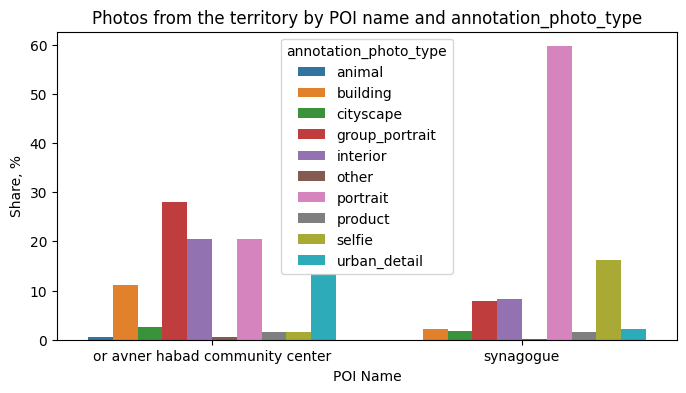

In [162]:
visualize_poi_photo_type(buildings_df)

In [ ]:
pd.set_option('display.max_colwidth', 1000)

feor_buildings = buildings_df[(buildings_df.annotation_photo_type == "building") & (buildings_df.poi_name == "or avner habad community center")]
feor_buildings[["image_url", "annotation_text_description", "annotation_user_intent", "annotation_has_feor", "annotation_has_synagogue"]]


,image_url,annotation_text_description,annotation_user_intent,annotation_has_feor,annotation_has_synagogue
13,"https://sun9-82.userapi.com/s/v1/ig1/EeOdHg7Z3Mns2qWiscfz4xzeKykALU5g4ob875hcPy9oIE-Od5Shp2mc6Ec_AwWvuqEVIxX_.jpg?quality=96&as=32x43,48x64,72x96,108x144,160x214,240x320,360x481,480x641,540x721,640x855,719x960&from=bu&cs=719x0","Стеклянный фасад с шестиугольной плиткой, отражающие деревья и небо; внизу виден логотип 'SOTA'",показать здание/архитектуру,False,False
176,"https://sun9-86.userapi.com/s/v1/if2/SHXbvy_2f1co9NxUOWt9S8ctp8Lz3l7wjJIsLiHLY9GNbAhX8V8f26jFVXMwWUfN9BmLU4bxB8m3IkfURdGG_gh4.jpg?quality=96&as=32x24,48x36,72x54,108x81,160x120,240x180,360x270,480x360,540x405,640x480,720x540,1080x810,1280x960,1440x1080,2560x1920&from=bu&cs=2560x0","Фасад здания с магазинами на первом этаже, на фасаде видны вывески; перед входами стоят люди, вокруг газон и кустарники.",задокументировать городскую сцену,False,False
297,"https://sun9-70.userapi.com/s/v1/if2/ba3JiFawK4BYrlv9c3IfuY-cxAbQbA_ihgphJu-3NPxIAwtH4zIWRCRYQtN_CiYD4MDl_EJLBhwLJF4DvMeeQnN9.jpg?quality=96&as=32x24,48x36,72x54,108x81,160x120,240x180,360x270,480x360,540x405,640x480,720x540,1080x810,1280x960&from=bu&cs=1280x0","Желтое здание с магазинами на первом этаже; витрины и вывески над входами, мокрый тротуар, ветка, упавшая на землю, белый забор перед газоном",показать фасад здания с магазинами на улице,False,False
413,"https://sun9-40.userapi.com/s/v1/if1/wWPYvfJ8hTqA-oswgpNMeF1ptmKMCGPRAYcrPMp3tj-w8OW4ZNua7kbYo1VQXCL7wiKNDflO.jpg?quality=96&as=32x18,48x27,72x41,108x61,160x90,240x135,360x203,480x270,540x304,640x360,720x405,1080x608,1280x720,1440x811,2560x1441&from=bu&cs=2560x0","Улица перед жилым многоквартирным домом: тротуар, забор, небольшой пандус и растительность у фасада; на стене граффити.",показать фасад здания на улице и придомовую территорию,False,False
549,"https://sun9-79.userapi.com/s/v1/if2/yDHyJ4ynwcUUzkaSmTFg0gR4zPOG-dsBjTCPq2lnHRcfaxaL1O9MuUEuiExesAwcLHF10nh8qNh3HpO2t7qgfOUg.jpg?quality=95&as=32x15,48x22,72x33,108x50,160x74,240x111,360x166,480x221,540x249,640x295,720x332,1080x498,1280x590,1440x664,2560x1180&from=bu&cs=2560x0","Фасад магазинов вдоль улицы, на газоне перед входами размещены крупные оранжевые буквы",показать фасад магазина и улицу,False,False
571,"https://sun9-7.userapi.com/s/v1/if2/5-jhXRE0hloIdrTiO03hx1_Be78YsgtcRKKeBOZeZiOqATQ3boZoIdLL2vsuqsZKjZ4VW1JKEC8Asky5eRpL5Wxz.jpg?quality=96&as=32x24,48x36,72x54,108x81,160x120,240x180,360x270,480x360,540x405,640x480,720x540,1080x810,1280x960&from=bu&cs=1280x0","Фасад желтого кирпичного здания по улице с вывесками, белый забор и голые ветви деревьев на переднем плане",показать фасад здания с вывесками,False,False
871,"https://sun9-88.userapi.com/s/v1/ig1/uhp0MQzZtweAmJse_P1mTdHnTAwqRFP42GVd8Q6ffgrwqhbzvN-0xRgO1UVToyTKP268FGx7.jpg?quality=96&as=32x43,48x64,72x96,108x144,160x213,240x320,360x480,480x640,540x720,640x853,720x960&from=bu&cs=720x0","Стеклянный фасад здания с шестигранными панелями; на лестнице работают люди, и идёт процесс нанесения надписи на стекло, в отражении видны соседние дома и автомобили.",показать фасад здания и рабочий процесс на лестнице,False,False
985,"https://sun9-17.userapi.com/s/v1/ig2/0x_eVXth7sgKhwR6H1UusonLiV7tKCC9evOIO12y2stWyWHyX8vceMxbRQu3IkWRvkmrKPToa5JVZ3ZHM-Muko6t.jpg?quality=95&as=32x43,48x64,72x96,108x144,160x213,240x320,360x480,480x640,540x720,640x853,720x960,1080x1440,1280x1707,1440x1920,1920x2560&from=bu&cs=1920x0","Красное кирпичное здание с белыми декоративными элементами на улице; рядом деревья, тротуар и дорожная часть видны слева",показать здание,False,False
2097,"https://sun9-8.userapi.com/s/v1/ig2/1Pnnszs_h-yzAXVk7l1j-BlSn5Csr4xxJdY9AuDXAJuweztJsWKaR8Ww1XVG6-WktLJSVP6Jyrn0aIi7wHrOKZF6.jpg?quality=95&as=32x43,48x64,72x96,108x144,160x213,240x320,360x480,480x640,540x720,640x853,720x960,1080x1440,1200x1600&from=bu&cs=1200x0","Высокое здание с фасадом из шестиугольных стеклянных панелей, вход у нижнего этажа, над входом видна вывеска SOTA","показать 

In [196]:
synagogue_buildings = buildings_df[buildings_df.poi_name == "synagogue"]
synagogue_buildings[["image_url", "annotation_text_description", "annotation_user_intent", "annotation_has_synagogue"]].to_csv("synagogue_buildings.csv", index=False)

feor_buildings = buildings_df[buildings_df.poi_name == "or avner habad community center"]
feor_buildings[["image_url", "annotation_text_description", "annotation_user_intent", "annotation_has_feor", "annotation_has_synagogue"]].to_csv("feor_buildings.csv", index=False)

## Part 2. 
Trying to clusterize photographs

In [22]:
! pip install scikit-learn

  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 14.7 MB/s eta 0:00:0000:0100:01
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 11.3 MB/s eta 0:00:0000:0100:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [26]:
cluster_df = df.copy()
cluster_df["annotation_text_description"] = cluster_df["annotation_text_description"].fillna("")

In [94]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# convert text to TF–IDF vectors
vectorizer = TfidfVectorizer(
    stop_words=None,
    min_df=2,                # tweak for your data size
    max_features=5000        # guard against sparse noise
)
tfidf = vectorizer.fit_transform(cluster_df["annotation_text_description"])

k = 15
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
cluster_df["cluster"] = kmeans.fit_predict(tfidf)

print(cluster_df[["photo_id", "cluster", "annotation_text_description"]])

       photo_id  cluster                        annotation_text_description
0     423419286        5    Ожерелье из жемчуга на белом фоне, крупный план
1     457250512        4  Женщина позирует внутри комнаты: в тёмном пидж...
2     403011859        1  Женщина в клетчатом пальто делает селфи в зерк...
3     457239063        6  Интерьер ночного заведения: синяя/фиолетовая п...
4     457257194        2  Женщина в интерьере перед белой стеной, позиру...
...         ...      ...                                                ...
5800  457257552        4  Женщина в белой майке и черных спортивных шорт...
5801  457247686        6  ночная уличная сцена с висящими красными фонар...
5802  457259864        6  Человек в черной куртке и шапке позирует на от...
5803  457256811       14  Полноразмерная портретная фотография женщины в...
5804  456239028        6  Серая балаклава/шапка балаклава с прорезью для...

[5805 rows x 3 columns]


In [47]:
cluster_df.groupby("cluster").size().reset_index(name="count")

,cluster,count
0,0,236
1,1,100
2,2,170
3,3,836
4,4,186
5,5,95
6,6,287
7,7,118
8,8,115
9,9,108


In [96]:
cluster_df[cluster_df["cluster"] == 0].annotation_text_description

15      Серое меховое пальто на вешалке на фоне деревя...
23      Полосатый свитшот с горизонтальными полосами р...
47      Хаки куртка-парка на вешалке перед горизонталь...
52      Белый пуховый жилет на вешалке висит перед бел...
55      Две кофты на вешалках висят перед деревянной с...
                              ...                        
5629    Зеленый свитшот на вешалке перед белыми жалюзи...
5666      Черная пуховая куртка висит на деревянной стене
5695    Серый пуховик на плечиках перед деревянной стеной
5742    Худи разных цветов на вешалке в магазине рядом...
5747    Черные спортивные штаны на вешалке перед белой...
Name: annotation_text_description, Length: 276, dtype: object